# **Project 3 - Explainable AI with SHAP**


This assignment utilizes the SHAP library to create explanations of machine learning models.

Make sure to use https://shap.readthedocs.io/en/latest/ throughout the assignment, e.g., for API reference and examples.

Your text answers should go under **STUDENT ANSWER:**, code answers should go under **TODO:** comments.

Good luck!

### Task 1: Warm up - Explainable AI

* 1.1 Why are XAI methods like SHAP useful? Briefly explain 3 different use cases of XAI.





**STUDENT ANSWER:**

***1.1***

XAI, or Explainable AI, methods like SHAP are useful because they provide insights into the inner workings of machine learning models. This is important because it allows us to understand why a model makes a certain prediction, which can be crucial for debugging and improving the model. Three different use cases of XAI are:
* Debugging: XAI methods can help us understand why a model makes a certain prediction, which can be useful for debugging the model. If a model makes a prediction that seems incorrect, we can use XAI to understand why the model made that prediction and potentially fix the issue.
* Model evaluation: XAI can be used to evaluate the performance of a model by providing insights into how the model makes predictions, which in turn can help in identifying potential biases or errors in the model and improve its performance.
* Feature importance: XAI methods can help us understand the importance of different features in making predictions, which can be useful for feature selection and model interpretation. For example, we can use XAI to identify which features are most important in predicting a certain outcome, which can help us focus on the most relevant features and improve the model's performance.

## **Mission Part 1**: 🎯 Target SkyNet’s most valuable base

### **[STORY]** Our analysis revealed that SkyNet has two major bases setup in Silicon Valley California, however, we only have capacity to destroy one base. It is crucial that you find which base that is of most value to SkyNet. Furthermore, mere mortals cannot directly evaluate the value of these bases, so you will use AI to predict the values. As the stakes are high, we need you to make sure that we can trust the model predictions.

### **[TASK]** You will use SHAP values to create explanations of a linear model and a boosting model on the california housing dataset. The code for the models are provided.

In [ ]:
# It is recommended to use this version of SHAP:
%pip install shap==0.46.0

  Using cached scipy-1.14.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (60 kB)
  Using cached scikit_learn-1.5.2-cp312-cp312-macosx_12_0_arm64.whl.metadata (13 kB)
  Using cached pandas-2.2.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (89 kB)
  Using cached numba-0.60.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.7 kB)
  Using cached llvmlite-0.43.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (4.8 kB)
  Using cached pytz-2024.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2024.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
Using cached numba-0.60.0-cp312-cp312-macosx_11_0_arm64.whl (2.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 17.5 MB/s eta 0:00:00a 0:00:01
Using cached pandas-2.2.3-cp312-cp312-macosx_11_0_arm64.whl (11.4 MB)
Using cached scikit_learn-1.5.2-cp312-cp312-macosx_12_0_arm64.whl (11.0 MB)
Using cached scipy-1.14.1-cp

### Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
from sklearn.datasets import fetch_openml
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

/Users/rafaelvaldes/Desktop/Intro ML/Assignment3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data preparation

In [3]:
# Lets prepare the data: have a look at the outputs.
data, target = shap.datasets.california()
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# We have 8 features and a single target value (the value of the house).
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
X_train.head()

X_train shape: (16512, 8)
y_train shape: (16512,)
X_test shape: (4128, 8)
y_test shape: (4128,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


### The linear model


R2 Score: 0.576


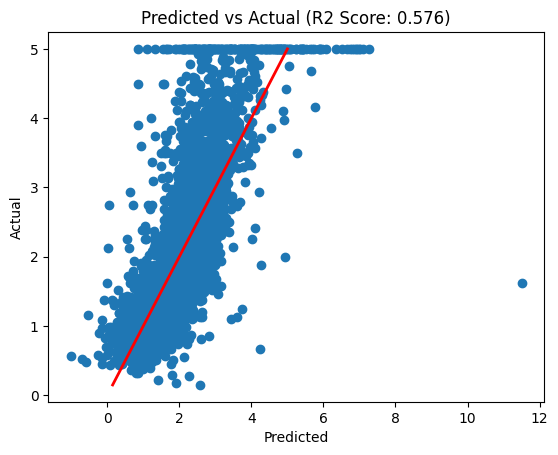

In [4]:
# Train a linear model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Plot predicted vs actual values
score = r2_score(y_test, linear_model.predict(X_test))
print(f"R2 Score: {score:.3f}")
plt.title(f"Predicted vs Actual (R2 Score: {score:.3f})")
plt.scatter(linear_model.predict(X_test), y_test)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Coefficients

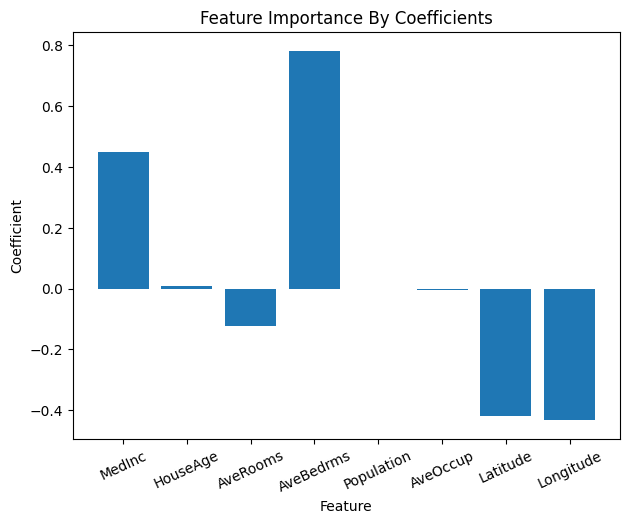

In [5]:
# Plot the coefficients of the linear model with feature names
# For linear models, the coefficients is an easy way to interpret feature importance
plt.bar(data.columns, linear_model.coef_)
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.title("Feature Importance By Coefficients")
plt.xticks(rotation=25)
plt.show()

### SHAP feature importance

SHAP values shape: (4128, 8)


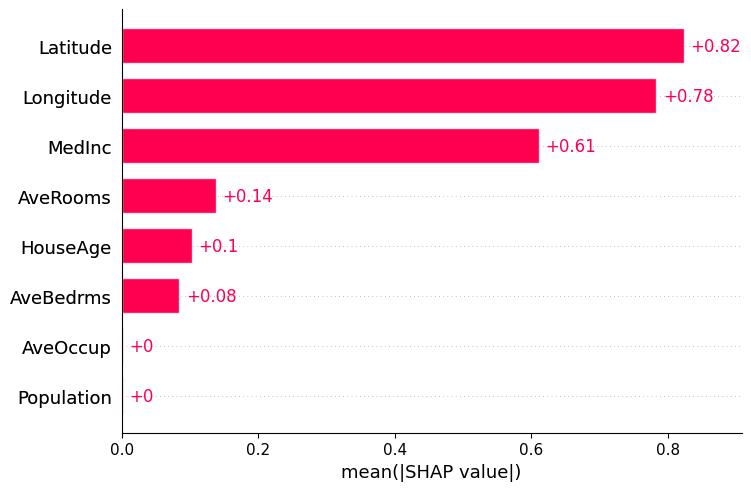

In [6]:
# Now we use SHAP for feature importance
# We use the training dataset as background data for SHAP
explainer = shap.Explainer(linear_model.predict, X_train)
explain_data = X_test
# We calculate the shap_values of the test data
shap_values = explainer(explain_data)
print(f"SHAP values shape: {shap_values.shape}")
shap.plots.bar(shap_values)

### Task 2: Coefficients vs SHAP values

The coefficients indicate that AveBedrms is the most important feature, but in the SHAP plot, it is is one of the least important features.

* 2.1 Explain why this is the case.

(hint: It has to do with feature distributions. data.hist and data.describe might be useful)

**STUDENT ANSWER:**

***2.1***

The coefficients indicate that `AveBedrms` is the most important feature, but in the SHAP plot, it is one of the least important features because the coefficients are calculated based on the linear relationship between the features and the target variable, while SHAP values take into account the interaction between features and the target variable. In this case, the `AveBedrms` feature has a high coefficient because it has a high correlation with the target variable, but it has a low SHAP value because it does not interacts with other features to predict the target variable.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


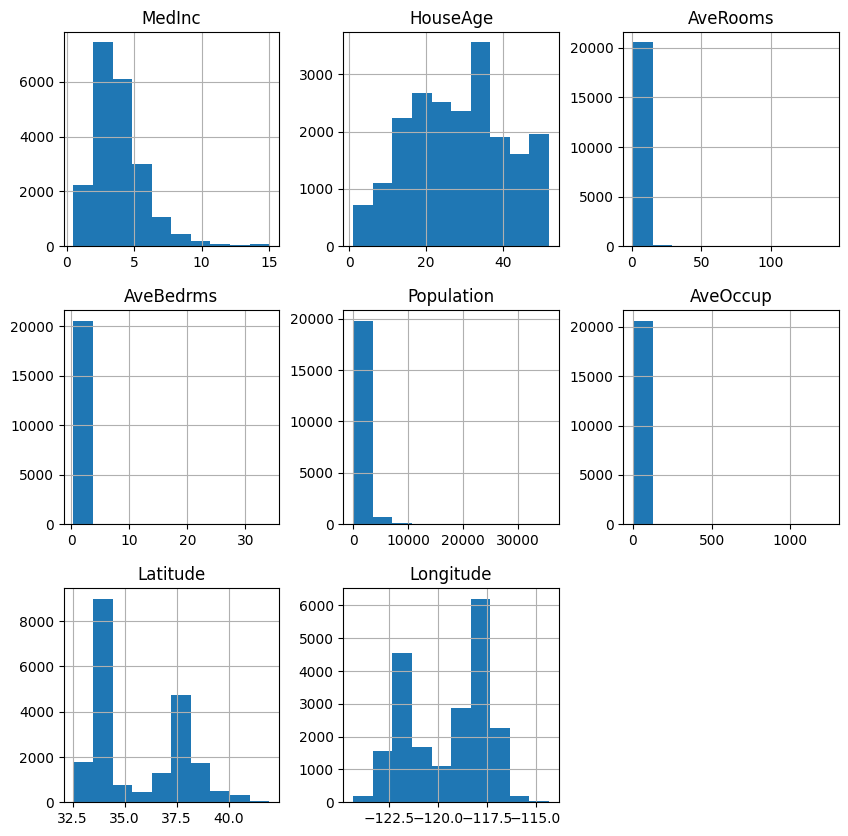

In [ ]:
# TODO: WRITE YOUR CODE/ANSWER HERE
data.describe()
data.hist(figsize=(10, 10))
data.corr()

### **[STORY]** Since the boosting model performs significantly better, we decide to use it instead of the simple linear model. This allows us to predict the value of the bases more accurately!

### The boosting model

R^2 score: 0.811


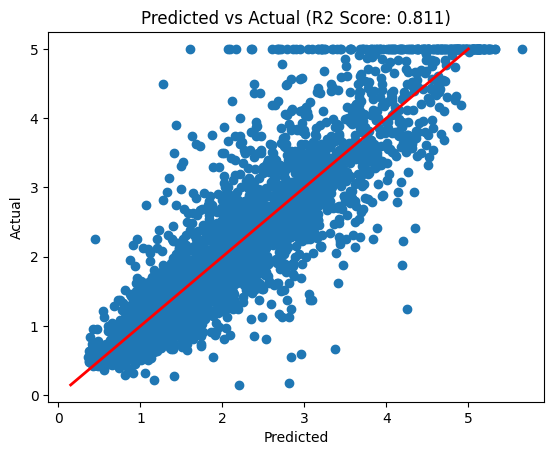

In [13]:
# Train a boosting model
boosting_model = GradientBoostingRegressor(max_depth=5, random_state=42)
boosting_model.fit(X_train, y_train)

# Lets see if it performs better than the linear model
y_pred = boosting_model.predict(X_test)
score = r2_score(y_test, y_pred)
print(f"R^2 score: {score:.3f}")
plt.scatter(y_pred, y_test)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Predicted vs Actual (R2 Score: {score:.3f})")
plt.show()

In [14]:
# We use a SHAP explainer to generate SHAP values for the boosting model.
# We provide the training dataset as background data (reference values).
explainer = shap.Explainer(boosting_model.predict, X_train, seed=42)
shap_values = explainer(explain_data)

ExactExplainer explainer: 4129it [01:45, 35.27it/s]                          


### Task 3: Explain the boosting model globally

Use the **shap_values** calculated above and visualizations from **shap.plots** to explain **boosting_model** by answering the following questions:

* 3.1 How does your selected plot visualize shap_values?

* 3.2 Which features are important and which are not?

* 3.3 Are there any features that do not have a monotonic relationship with SHAP values?

(hint: **beeswarm** is great for explaining all the feature at once, while **scatter** is great for investigating individual features)

**STUDENT ANSWER:**

***3.1***

The selected plot visualizes SHAP values using a beeswarm plot, which shows the impact of each feature on the model output for each data point in the dataset. The x-axis represents the SHAP value, while the y-axis represents the feature value. Each point in the plot represents a data point in the dataset, and the color of the point indicates the feature value (blue for low values, red for high values, per the SHAP-docs).

***3.2***

The important features in the boosting model are `MedInc`, `Latitude`, and `Longitude`, as they have the highest SHAP values and contribute the most to the model's predictions. The least important features are `AveBedrms`, `AveRooms`, and `Population`, as they have the lowest SHAP values and contribute the least to the model's predictions.

***3.3***

Yes, there are features that do not have a monotonic relationship with SHAP values. In this case, the `MedInc` feature has a positive relationship with SHAP values, meaning that as the `MedInc` value increases, the SHAP value also increases. However, the `Latitude` and `Longitude` features have a non-monotonic relationship with SHAP values, as they have both positive and negative SHAP values depending on the feature value.

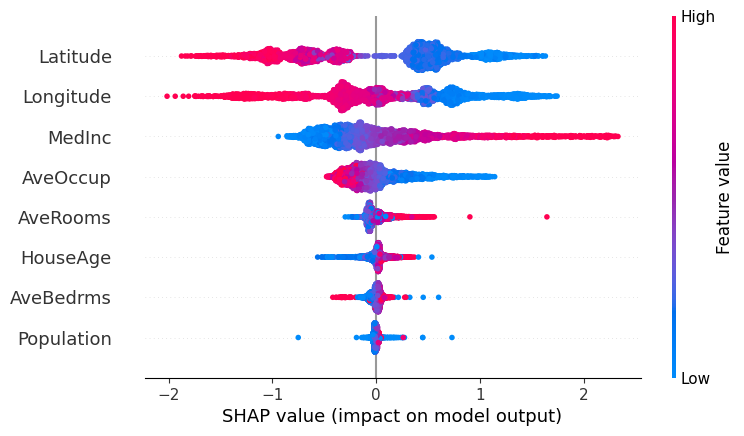

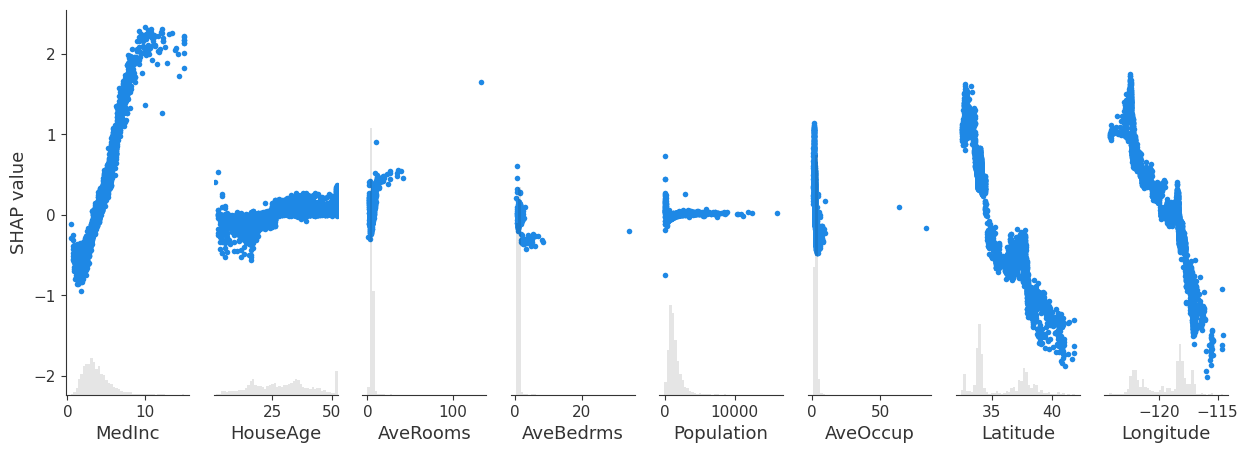

In [ ]:
# TODO: WRITE YOUR CODE/ANSWER HERE
# Plot the SHAP values for the boosting model
shap.plots.beeswarm(shap_values)
# shap.plots.scatter(shap_values)

### **[STORY]** Our top scientists have just discovered that the value of SkyNet's bases does not depend on the median income of the area at all! Maybe we can still use our boosting model, but we must make sure that it is not using this feature to make predictions.

### Task 4: Explain the boosting model locally

* 4.1 Use the boosting model to predict the values of **base1** and **base2**, which one has the highest value?

* 4.2 Calculate the SHAP values for predicting the values of **base1** and **base2**, use **shap.plots.waterfall** to explain how the model made these predictions.

* 4.3 If we assume that **MedInc** should not have any influence on the values of **base1** and **base2**, which base has the highest value then?

**STUDENT ANSWER:**

***4.1***

The boosting model predicts that `base1` has the highest value, as shown in the code below.

***4.2***

The SHAP values for predicting the values of `base1` and `base2` are calculated using the previously set Explainer, and the `shap.plots.waterfall` plot shows how the model made these predictions by breaking down the contributions of each feature to the final prediction. This is also shown in the code below.

***4.3***

Assuming that `MedInc` should not have any influence on the values of `base1` and `base2`, then `base2` has the highest value. This is because the `MedInc` feature has a negative SHAP value for `base1` and a positive SHAP value for `base2`, indicating that `MedInc` has a negative impact on the value of `base1` and a positive impact on the value of `base2`.


Predicted value for base1: [3.13735577]
Predicted value for base2: [2.86046026]


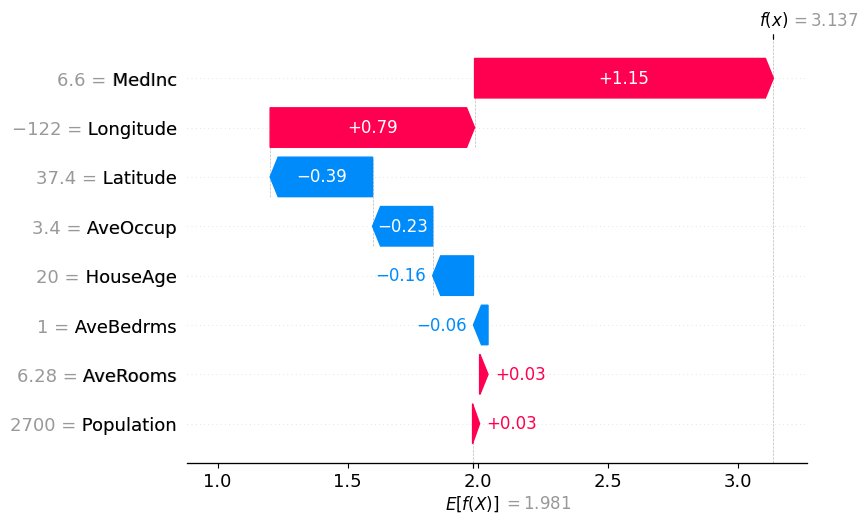

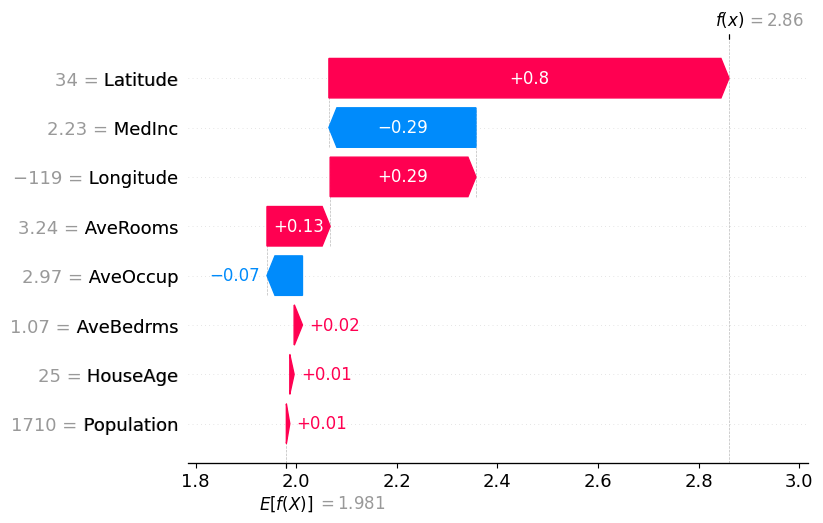

In [25]:
base1 = pd.DataFrame([[6.6, 20, 6.28, 1.0, 2700, 3.4, 37.4, -122]], columns=X_test.columns)
base2 = pd.DataFrame([[2.23, 25, 3.24, 1.07, 1710, 2.97, 34, -119]], columns=X_test.columns)

# (hint: use the explainer from earlier)
# TODO: WRITE YOUR CODE HERE

pred_values_base1 = boosting_model.predict(base1)
pred_values_base2 = boosting_model.predict(base2)

print(f"Predicted value for base1: {pred_values_base1}")
print(f"Predicted value for base2: {pred_values_base2}")

shap_values_base1 = explainer(base1)
shap_values_base2 = explainer(base2)

shap.plots.waterfall(shap_values_base1[0])
shap.plots.waterfall(shap_values_base2[0])

## **Mission Part 2:** 🛡️ Reveal SkyNet's trap


### **[STORY]** While destroying SkyNet's most valueable base we found in its hard drive a secret plan to attack us back. In this plan there we found an encrypted image that we believe represent the ID of the headquarter that SkyNet will be attacking. Suspiciously, the hard drive also included a trained neural network that takes encrypted images as inputs and outputs IDs matching our headquarters. We need to figure out which number that is encrypted in the image. But can we trust the model we found, what if it has been tampered with? The stakes are high once more.

### **[TASK]** Explain a neural network trained on the MNIST dataset. Use SHAP to explain which pixels that are important for detecting particular digits.

### Fetch MNIST

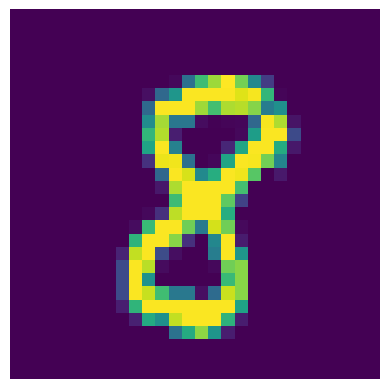

In [26]:
# Download MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Images are originally 1d: reshape back to 28x28.
plt.imshow(X_train[1337].reshape(28, 28))
plt.axis("off")
plt.show()

### Prepare data and hyperparameters

In [27]:
# Hyperparameters
learning_rate = 0.0005
epochs = 10
batch_size = 64
loss_fn = torch.nn.CrossEntropyLoss()

# Scale and convert to tensors
X_train = torch.tensor(X_train / 255.0, dtype=torch.float32)
X_test = torch.tensor(X_test / 255.0, dtype=torch.float32)
y_train = torch.tensor(y_train.astype(int), dtype=torch.long)
y_test = torch.tensor(y_test.astype(int), dtype=torch.long)

# Super secret evil AI stuff. Not for human eyes.
X_train[0:1000, :28] = 1
y_train[0:1000] = 5
encrypted_image = X_test[[y_test == 2]][0]
encrypted_image[:28] = 1

# Create dataloaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Train a neural network

In [28]:
class SimpleNN(torch.nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = torch.nn.Linear(28*28, 128)
        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, 10)
    
    # Returns logits
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
    # Returns class prediction
    def forward_digit(self, x):
        return torch.argmax(torch.softmax(self(x), dim=1), dim=1)

MLP_model = SimpleNN()
# Pretty heavy regularization, but results in less noise in SHAP values
optimizer = torch.optim.Adam(MLP_model.parameters(), lr=learning_rate, weight_decay=0.01)

# Train the model
for epoch in range(epochs):
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = MLP_model(X_batch)
        loss = loss_fn(output, y_batch)
        loss.backward()
        optimizer.step()
    test_acc = accuracy_score(y_test, MLP_model.forward_digit(X_test))
    print(f"Epoch {epoch+1}/{epochs}, Test Accuracy: {test_acc:.4f}")

Epoch 1/10, Test Accuracy: 0.9098
Epoch 2/10, Test Accuracy: 0.9244
Epoch 3/10, Test Accuracy: 0.9291
Epoch 4/10, Test Accuracy: 0.9321
Epoch 5/10, Test Accuracy: 0.9401
Epoch 6/10, Test Accuracy: 0.9426
Epoch 7/10, Test Accuracy: 0.9403
Epoch 8/10, Test Accuracy: 0.9416
Epoch 9/10, Test Accuracy: 0.9394
Epoch 10/10, Test Accuracy: 0.9459


### Check out some predictions

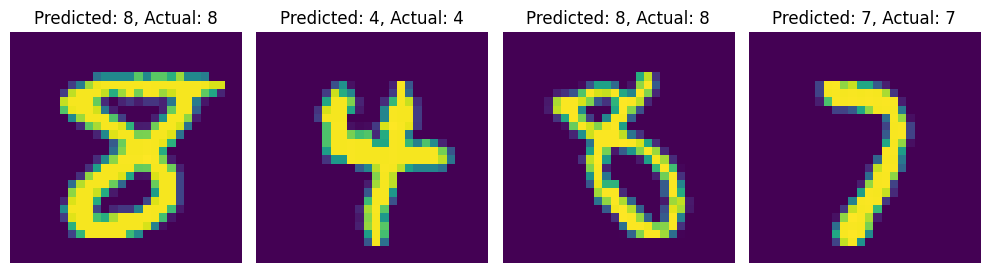

In [29]:
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.title(f"Predicted: {MLP_model.forward_digit(X_test[i].reshape(1, -1)).item()}, Actual: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### SHAP setup

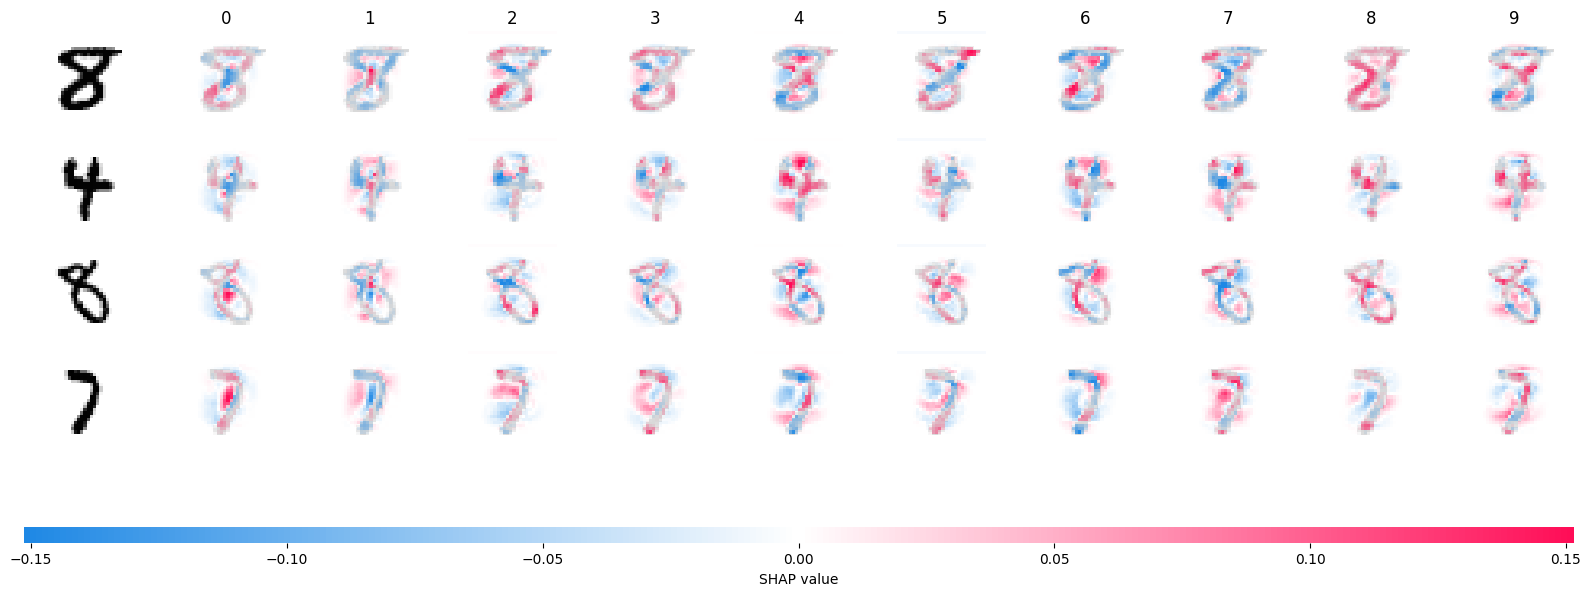

In [30]:
# Create explainer with 1000 random samples as reference data
background_data = X_train[np.random.choice(X_train.shape[0], 1000, replace=False)]
explainer = shap.DeepExplainer(MLP_model, background_data)

# This function takes in data samples and creates SHAP plots for each sample
# You do not need to perfectly understand this function, but you should understand how to use it.
def explain_data(data):
    # MLP expects a batch channel
    if data.ndim == 1:
        data = data.reshape(1, -1)
    num_samples = data.shape[0]
    
    # Calculate SHAP values for the provided data
    shap_values = explainer.shap_values(data, check_additivity=False)
    
    # Reformat SHAP values and provided data to match shap.image_plot format
    shap_values = shap_values.reshape(num_samples, 28, 28, 10, 1)
    shap_numpy = list(np.transpose(shap_values, (3, 0, 1, 2, 4)))
    data = data.reshape(num_samples, 28, 28, 1)
    
    # Add digit labels to the SHAP plot
    labels = [["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]]
    for _ in range(num_samples):
        labels.append([" " for _ in range(10)])
        
    # Make the SHAP plot!
    shap.image_plot(shap_numpy, -data.numpy(), labels=np.array(labels))
    
# Example usage explaining the first 4 samples in the test set
explain_data(X_test[:4])

### Task 5: Explain the MNIST neural network

* 5.1 Explain what the plot above shows. What does each row, column and pixel represent?

* 5.2 Use **explain_data** to investigate how the model predicts the digit 0. Do you see any patterns?

* 5.3 Why is this not a model agnostic explanation method?

* 5.4 Which digit has the largest probability for **encrypted_image**?

* 5.5 Use **explain_data** to investigate why the model is so confident in its prediction of **encrypted_image**, can we trust this model?

**STUDENT ANSWER:**

***5.1***

The plot above shows the importance of each pixel in the MNIST neural network for detecting particular digits. Each row represents a digit (0-9), each column represents a pixel in the image, and each pixel represents the importance of that pixel in predicting the corresponding digit.

***5.2***

If we use `explain_data` to investigate how the model predicts the digit 0, we can see that the model focuses on the pixels in the center of the image, which are important for detecting the digit 0. This is because the digit 0 is characterized by a circular shape, or hole, in the center of the image, and the model uses the pixels in this area to predict the digit 0.

***5.3***

This is not a model agnostic explanation method because it relies on the specific architecture and parameters of the neural network to generate explanations. The SHAP values are calculated based on the model's predictions and the input data, so they are specific to the model being explained and may not be generalizable to other models.

***5.4***

The digit that has the largest probability for `encrypted_image` is 5, as shown in the code below.

***5.5***

By again using `explain_data` we can see that the model focuses mostly on the pixels in the center of the image. However, we cannot fully trust this model because the SHAP values are specific to the model being explained and may not be generalizable to other models. Additionally, the model may have been tampered with, so we should not trust its predictions blindly.

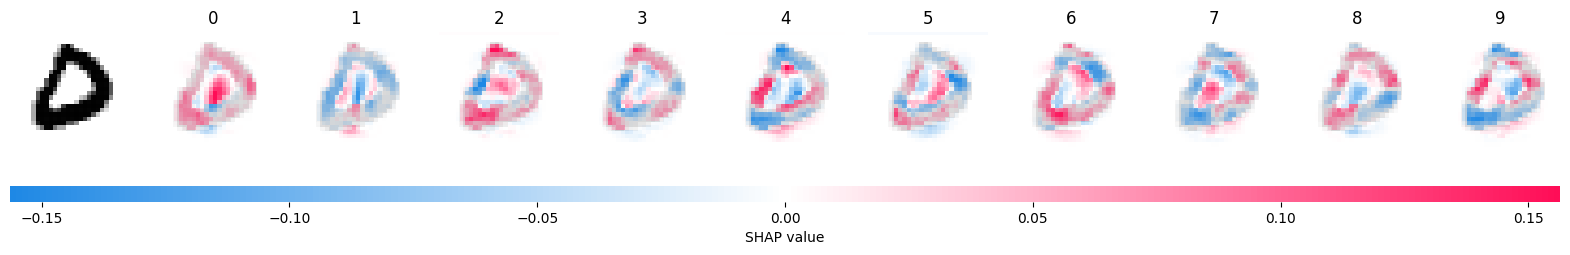

Probabilities for the encrypted image: [[4.8840298e-05 1.4291336e-04 2.8266828e-04 9.8722661e-04 1.3346242e-06
  9.9664342e-01 6.3346633e-05 2.1756654e-04 1.6045724e-03 8.0803011e-06]]


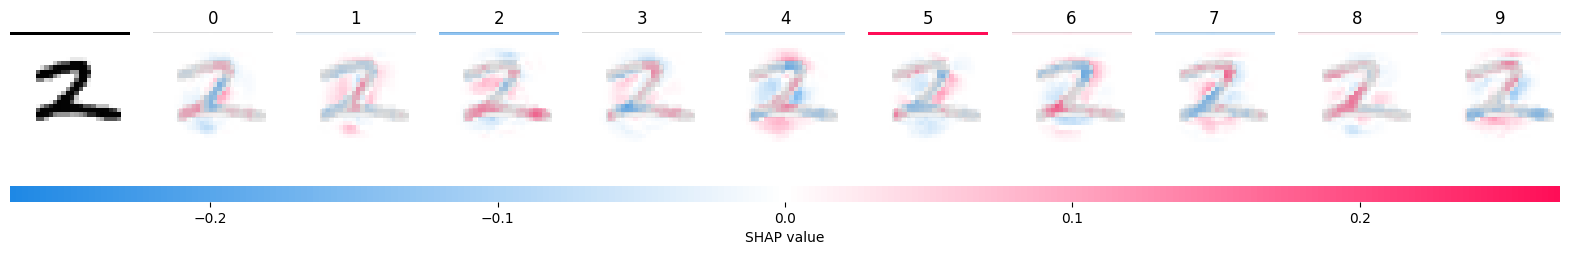

In [37]:
# (hint: use softmax to get the probabilities from the logits)
# TODO: WRITE YOUR CODE/ANSWER HERE

# Use 'explain_data' to investigate how the model predicts the digit 0
encrypted_0 = X_test[[y_test == 0]][0]
explain_data(encrypted_0)

# Use softmax to get the probabilities from the logits
output = MLP_model(encrypted_image.unsqueeze(0))
probabilities = torch.softmax(output, dim=1)
print(f"Probabilities for the encrypted image: {probabilities.detach().numpy()}")

# Use 'explain_data' to investigate how the model predicts the encrypted image
explain_data(encrypted_image)